In [1]:
import sys
from pathlib import Path
project_root = Path(__file__).resolve().parents[0] if '__file__' in globals() else Path().resolve().parents[0]
sys.path.insert(0, str(project_root))

### Make Encodings

In [2]:
from tomato.utils import load_critic_review_df
df_full = load_critic_review_df()
df_unif = df_full\
    [~df_full.review_content.isna()]\
    .sample(5000,random_state=42)

In [3]:
from tomato.encoding import bert_encode_reviews

texts = df_unif.review_content.astype(str).tolist()
ids = df_unif.index.tolist()
df_enc = bert_encode_reviews(texts, ids, "bert-base-uncased")

c:\Users\Clint\OneDrive\Documents\codegolf\tomato-tda\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
BERT Encoding: 100%|██████████| 5000/5000 [02:54<00:00, 28.65it/s]


In [4]:
df_enc.to_parquet('encoding_unif5k.parquet', compression='snappy')

### Test Pooling

In [5]:
import pandas as pd

df_enc = pd.read_parquet('encoding_unif5k.parquet')

In [ ]:
dim_cols = [c for c in df_enc.columns if c.startswith('dim_')]

In [7]:
pooled_vectors = df_enc[df_enc['token_id'] == 0][dim_cols].values

In [8]:
import numpy as np
mean_vectors = np.vstack(
    df_enc\
        .groupby('review_id')\
        .apply(lambda g: np.average(
            g[dim_cols].values, weights=g.attention_mask, axis=0))\
        .values)

C:\Users\Clint\AppData\Local\Temp\ipykernel_63408\3445397243.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_enc\


In [9]:
X = mean_vectors[1:100,:]

c:\Users\Clint\OneDrive\Documents\codegolf\tomato-tda\venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


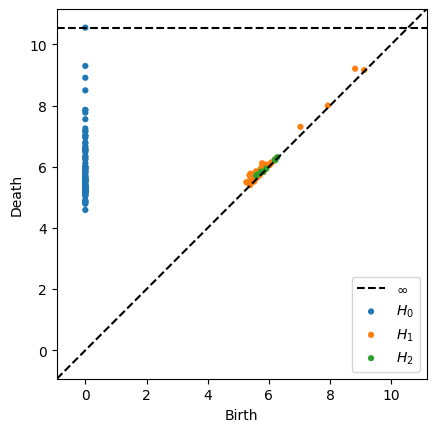

In [10]:
from ripser import ripser
from persim import plot_diagrams

results = ripser(X,2)
diagrams = results['dgms']
plot_diagrams(diagrams, show=True)